# importing libraries 

In [34]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# importing data

In [35]:
print(os.getcwd())
filepath = os.path.join(os.path.dirname(os.getcwd()), 'data/dataset/processed/go_emotion_dutch.csv')

c:\Users\koenm\Documents\repositorys\year_2\fae2-nlpr-group-group-4-1\fae2-nlpr-group-group-4-1\nlp_cia\task 6


In [36]:
df_train = pd.read_csv(filepath)
df_train = df_train.sample(n=len(df_train))

In [37]:
df_train.head()

,Sentence,Emotion_core,value,Emotion_encoded
34457,Mijn verloofde had het op maat laten maken als...,happiness,1,0
18705,"Hé, snelle vraag hoe voeg je toernooipunten to...",surprise,1,2
46192,Hem persoonlijk bellen? Of in het bijzijn van ...,neutral,1,6
29081,Ik wou dat een schattig meisje naar me zou sta...,happiness,1,0
24065,Mijn fout als ik net /u/keypuncher en /u/ibite...,sadness,1,3


In [38]:
filepath_2 = os.path.join(os.path.dirname(os.getcwd()), "data/group_4_url_1_transcript.csv")
df_test = pd.read_csv(filepath_2)
df_test = df_test.sample(n=len(df_test))

In [39]:
df_test.head()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
215,1900-01-01 00:12:18.160000,1900-01-01 00:12:21.160000,En eigenlijk hetzelfde geldt voor Envelop 2.,And actually the same applies to Envelope 2.,indifference,neutral,neutral
451,1900-01-01 00:23:33.379000,1900-01-01 00:23:36.379000,"En als we die mee zouden nemen, daar moesten w...","And if we were to take those with us, we had t...",caution,fear,mild
126,1900-01-01 00:07:42,1900-01-01 00:07:44,"Ze ging af en toe een beetje links rijden, af ...","She occasionally drove a little to the left, o...",uncertainty,neutral,mild
337,1900-01-01 00:17:30.160000,1900-01-01 00:17:32.160000,Maar ik ben wel goed aan het kijken.,But I am paying close attention.,attentiveness,neutral,mild
844,1900-01-01 00:43:24.640000,1900-01-01 00:43:28.640000,"Het Engelse woord voor typemachine, typewriter...","The English word for typemachine, typewriter...",curiosity,neutral,neutral


# training model

In [40]:
# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=7000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['Sentence'])

model = MultinomialNB(alpha=1.0,                # Smoothing parameter (higher = more smoothing)
                      fit_prior=True).fit(X_train_tfidf, df_train['Emotion_core'])


# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Sentence'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(classification_report(df_test['Emotion_core'], predictions))

Accuracy:  0.384
Precision: 0.500
Recall:    0.384
F1-score:  0.348
              precision    recall  f1-score   support

       anger       1.00      0.05      0.10        37
     disgust       0.00      0.00      0.00        17
        fear       0.00      0.00      0.00        56
   happiness       0.25      0.82      0.38       198
     neutral       0.61      0.42      0.50       546
     sadness       0.83      0.05      0.09       104
    surprise       0.22      0.02      0.04        92

    accuracy                           0.38      1050
   macro avg       0.42      0.20      0.16      1050
weighted avg       0.50      0.38      0.35      1050



c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\koenm\miniconda3\envs\p12dupa\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

# hyper parameter tuning

In [41]:
# Try different alpha values
for alpha in [0.1, 0.5, 1.0, 2.0]:
    model = MultinomialNB(alpha=alpha).fit(X_train_tfidf, df_train['Emotion_core'])
    predictions = model.predict(X_test_tfidf)
    acc = accuracy_score(df_test['Emotion_core'], predictions)
    print(f"Alpha={alpha}: {acc:.3f}")

Alpha=0.1: 0.393
Alpha=0.5: 0.394
Alpha=1.0: 0.384
Alpha=2.0: 0.358


# error analysis

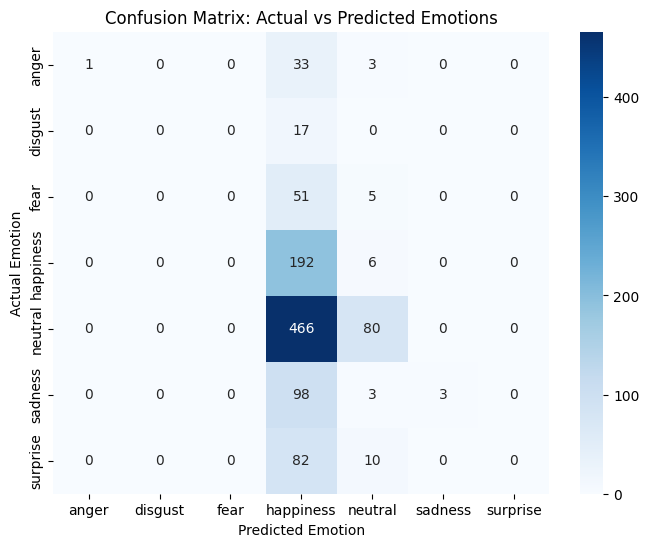


Prediction Distribution:
happiness    939
neutral      107
sadness        3
anger          1
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [42]:
# Train on df_train
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(df_train['Sentence'])
model = MultinomialNB().fit(X_train_tfidf, df_train['Emotion_core'])

# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Sentence'])
predictions = model.predict(X_test_tfidf)

# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())

In [43]:
# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=7000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['Sentence'])
model = LinearSVC(class_weight='balanced', max_iter=2000).fit(X_train_tfidf, df_train['Emotion_core'])

# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Sentence'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.490
Precision: 0.499
Recall:    0.490
F1-score:  0.492


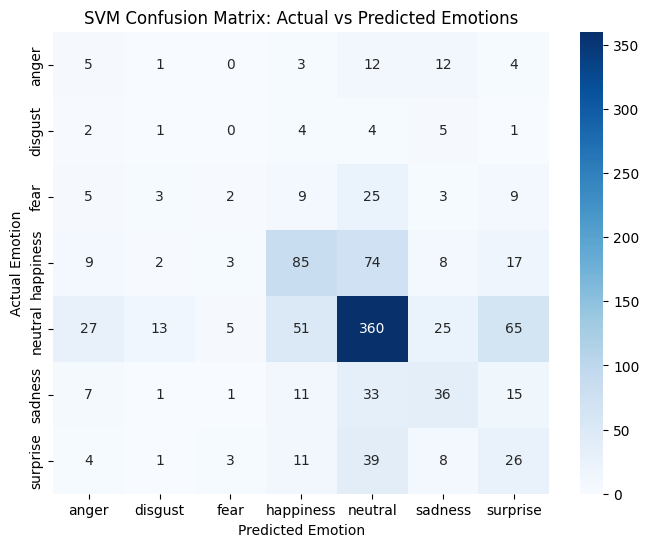


Prediction Distribution:
neutral      547
happiness    174
surprise     137
sadness       97
anger         59
disgust       22
fear          14
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [44]:
# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('SVM Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())